In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

root_str = str(PROJECT_ROOT)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

#print("PROJECT_ROOT =", PROJECT_ROOT)
#print("cwd =", Path.cwd())

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch

## input

In [4]:
from src.preprocessing import pp
from sklearn.model_selection import train_test_split
import scvi

In [32]:
control_key = "is_control"
condition_keys = "cytokine"
condition_rep_keys = "condition_embeddings"
random_seed = 42
dataset_name = "PBMC_donor7_hvg"
sample_rep = "X_pca" 
#sample_rep = "X_scVI" 
#sample_rep = "X_flatvi"
#sample_rep = "X_state"
if_adata_ref = True
adata_ref_path = "data/processed/PBMC_donor11_hvg_42_0.4_False_X_pca_scaled_100_control.h5ad"

In [33]:
filePath = f'./data/raw/{dataset_name}.h5ad'
adata = sc.read_h5ad(filePath)
print(adata)

AnnData object with n_obs × n_vars = 652386 × 5412
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    layers: 'counts'


In [34]:
adata.obs[control_key] = (adata.obs[condition_keys] == "PBS")
condition_list = adata[adata.obs[control_key]==False].obs[condition_keys].unique()
print(adata.obs[control_key].value_counts())

is_control
False    614570
True      37816
Name: count, dtype: int64


## splitting

In [35]:
#adata = adata[~adata.obs[condition_keys].isin(["LT-alpha2-beta1","IFN-lambda2","IFN-lambda3","IL-18Ra","LT-alpha1-beta2"])]

In [36]:
rng = np.random.default_rng(random_seed) 
test_ratio = 0.4
condition_list = list(condition_list)
zero_shot = True

if not zero_shot:
    # 分层抽样 先验证分布内学习能力
    pert_mask = adata.obs[control_key] == False
    y = adata.obs.loc[pert_mask, condition_keys].astype(str).values
    pert_indices = np.flatnonzero(pert_mask)

    train_idx, test_idx = train_test_split(
        pert_indices,
        test_size=test_ratio,
        random_state=random_seed,
        stratify=y 
    )
    adata_train = adata[train_idx].copy()
    adata_test = adata[test_idx].copy()
    adata_control = adata[adata.obs[control_key] == True].copy()
    adata_train.uns["normalized_m"] = 1 / (1-test_ratio)
    adata_test.uns["normalized_m"] = 1 / test_ratio
    adata_control.uns["normalized_m"] = 1 / 6
    print(condition_list)
else:
    # 按condition分割 zeroshot
    n_test = max(1, int(len(condition_list) * test_ratio))
    test_condition = rng.choice(condition_list, size=n_test, replace=False).tolist()
    print(test_condition)
    train_condition = [g for g in condition_list if g not in test_condition]
    print(train_condition)
    adata_control = adata[adata.obs[control_key]==True].copy() # control的target_condition是 PBS
    adata_train = adata[adata.obs[condition_keys].isin(train_condition)].copy() 
    adata_test = adata[adata.obs[condition_keys].isin(test_condition)].copy()
    adata_train.uns["normalized_m"] = 1
    adata_test.uns["normalized_m"] = 1
    adata_control.uns["normalized_m"] = 1 / 6

['IL-11', 'C5a', 'CD40L', 'TL1A', 'SCF', 'GM-CSF', 'IL-9', 'IL-20', 'IL-8', 'IFN-lambda1', 'IL-21', 'PSPN', 'IL-3', 'TWEAK', 'IL-16', 'PRL', 'Megalin', 'LT-alpha2-beta1', 'EPO', 'IL-36-alpha', 'IL-33', 'VEGF', 'CT-1', 'IL-15', 'FLT3L', 'IL-5', 'IL-10', 'IL-17F', 'IL-12', 'IFN-omega', 'OX40L', 'IL-23', 'M-CSF', 'CD27L', 'IL-19', 'IL-17A']
['4-1BBL', 'ADSF', 'APRIL', 'BAFF', 'CD30L', 'Decorin', 'EGF', 'FGF-beta', 'FasL', 'G-CSF', 'GDNF', 'GITRL', 'HGF', 'IFN-alpha1', 'IFN-beta', 'IFN-epsilon', 'IFN-gamma', 'IFN-lambda2', 'IFN-lambda3', 'IGF-1', 'IL-1-alpha', 'IL-1-beta', 'IL-13', 'IL-17B', 'IL-17C', 'IL-17D', 'IL-17E', 'IL-18Ra', 'IL-1Ra', 'IL-2', 'IL-22', 'IL-24', 'IL-26', 'IL-27', 'IL-31', 'IL-32-beta', 'IL-34', 'IL-35', 'IL-36Ra', 'IL-4', 'IL-6', 'IL-7', 'LIF', 'LIGHT', 'LT-alpha1-beta2', 'Leptin', 'Noggin', 'OSM', 'RANKL', 'LAP-TGF-beta1', 'TNF-alpha', 'TPO', 'TRAIL', 'TSLP']


In [37]:
del adata

## latent embedding

In [38]:
n_comps = 100
n_hidden = 512
n_layers = 2
condition_rep_dict = pd.read_pickle("./data/processed/PBMC_cytokines.pkl")
model_ref = None
model_train = None
model_test = None
scvi_save_path = f"./data/processed/model/{sample_rep}_ncomps{n_comps}_hidden{n_hidden}_layers{n_layers}_{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}"
flatvi_save_path = f"./data/processed/model/{sample_rep}_ncomps{n_comps}_hidden{n_hidden}_layers{n_layers}_{dataset_name}"
state_decoder_save_path = f"./data/processed/model/{sample_rep}_{dataset_name}"
model_save_path = None

load_embedding_model = True
if sample_rep in ["X_scVI"]:
    model_save_path = scvi_save_path
    if load_embedding_model:
        try:
            model_ref = scvi.model.SCVI.load(f"{model_save_path}_ref", adata=adata_control)
        except (FileNotFoundError, OSError, ValueError) as e:
            model_ref = None 
        try:
            model_train = scvi.model.SCVI.load(f"{model_save_path}_train", adata=adata_train)
        except (FileNotFoundError, OSError, ValueError) as e:
            model_train = None
        if adata_test is not None:
            try:
                model_test = scvi.model.SCVI.load(f"{model_save_path}_test", adata=adata_test)
            except (FileNotFoundError, OSError, ValueError) as e:
                model_test = None
elif sample_rep == "X_flatvi":
    model_save_path = flatvi_save_path
    if load_embedding_model:
        try:
            model_ref = scvi.model.SCVI.load(f"{flatvi_save_path}_ref", adata=adata_control)
        except (FileNotFoundError, OSError, ValueError) as e:
            model_ref = None 
elif sample_rep=="X_state":
    from src.preprocessing import build_train_eval_loaders,NBDecoderTrainer,NBDecoder
    model_save_path = state_decoder_save_path
    z_dim = adata_control.obsm["X_state"].shape[1] # 2058
    n_genes = adata_control.n_vars
    decoder = NBDecoder(z_dim=z_dim, n_genes=n_genes, hidden=(1024,2048,4096), dropout=0.1)
    train_loader, val_loader = build_train_eval_loaders(
                                    adata_train=adata_control,
                                    adata_eval=adata_train,   
                                    count_layer="counts",
                                    emb_key="X_state",
                                    batch_size=256,
                                )
    trainer = NBDecoderTrainer(decoder, lr=1e-4, device="cuda", use_amp=True)
    trainer.fit(train_loader, val_loader=val_loader, epochs=50)
    trainer.save(f"{state_decoder_save_path}.pt")

In [39]:
if if_adata_ref:
    adata_ref = sc.read_h5ad(adata_ref_path,backed='r')
else:
    adata_ref = None

In [40]:
adata_control, adata_train, adata_test, model_ref, model_train, model_test = pp.process_to_embedding( 
    adata_control,
    adata_train,
    adata_ref = adata_ref,
    adata_test = adata_test,
    sample_rep = sample_rep,
    n_comps = n_comps,
    n_hidden = n_hidden,
    n_layers = n_layers,
    model_ref = model_ref,
    model_train = model_train,
    model_test = model_test,
    model_save_path = model_save_path,
    control_key = control_key,
    condition_keys = condition_keys,
    condition_rep_keys = condition_rep_keys,
    batch_key = "gemgroup",
    condition_rep_dict = condition_rep_dict,
    pca_method = "scanpy", # "parse"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )
if sample_rep == "X_pca":
    sample_rep_scaled = sample_rep + "_scaled" # 额 别忘了
else:
    sample_rep_scaled = sample_rep

[0.53319466 0.885521   0.94933534 0.79978204 0.55273515 0.92781246
 0.7915584  0.7898243  0.9363081  0.88689595 1.0036138  0.6767904
 1.0353545  0.74302286 0.5673639  1.0324533  0.8438115  0.9677961
 1.0455606  1.0782423  1.0553452  0.99818444 0.9800445  0.9134084
 1.0214598  1.0613346  1.0096898  0.9829897  0.95051605 1.0117456
 0.96204776 0.9934761  0.96332425 0.97061574 0.9619064  0.9814763
 0.9741676  1.0138059  1.0419345  0.99607325 0.9875389  0.9715575
 0.9664726  0.9938691  0.9797154  0.96254295 1.0013198  0.99463004
 0.99989563 0.95240766 0.990698   0.98231596 0.972111   1.0142508
 0.944676   0.9886642  0.99048513 1.0246178  0.9998294  1.0088576
 0.90257007 0.9792476  0.9918814  1.0019796  0.9850594  1.0061021
 0.97121745 1.0350815  0.9665993  0.9948336  1.0005788  0.9970043
 1.0186727  0.97293043 0.98551226 0.99099815 0.9830571  0.96462613
 0.9903668  1.0043083  0.98547477 1.0078467  1.0114108  0.98763084
 0.9872595  0.97022873 0.9890939  1.0080116  1.017675   0.97294724
 0.99

In [41]:
preprocess_save_path = f"./data/processed/{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}_{sample_rep_scaled}_{n_comps}_{if_adata_ref}"
adata_control.write_h5ad(f"{preprocess_save_path}_control.h5ad")
adata_train.write_h5ad(f"{preprocess_save_path}_train.h5ad")
if adata_test is not None:
    adata_test.write_h5ad(f"{preprocess_save_path}_test.h5ad")

In [42]:
print(adata_control)
print(adata_train)
print(adata_test)

AnnData object with n_obs × n_vars = 37816 × 5412
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'is_control'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'normalized_m', 'pca'
    obsm: 'X_pca', 'X_pca_scaled'
    varm: 'PCs', 'X_mean'
    layers: 'counts'
AnnData object with n_obs × n_vars = 378269 × 5412
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'is_control'
    var: 'n_cells', 'highly_variable', 'means', 'dispersion

In [39]:
denoised_df = model_ref.get_normalized_expression(adata_control, return_mean=True,library_size=1e4)
raw_adata = adata_control.copy()
sc.pp.normalize_total(raw_adata, target_sum=1e4)
raw_matrix = raw_adata.X
if hasattr(raw_matrix, "toarray"):
    raw_matrix = raw_matrix.toarray()

Gene Mean Correlation (Raw vs Recon): 0.7838


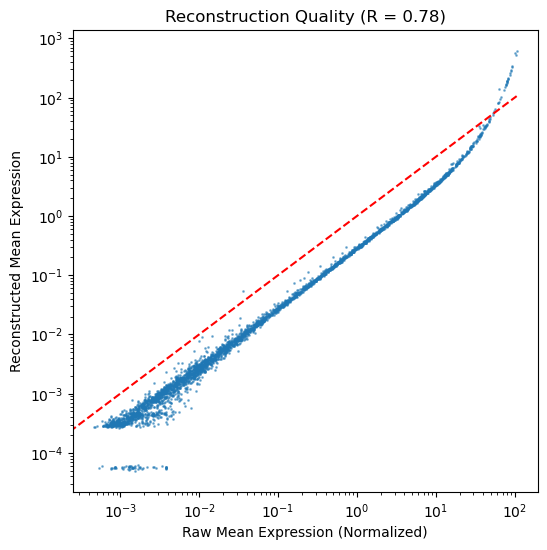

In [40]:
# 计算原始数据和重建数据的基因均值
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
mean_raw = np.mean(raw_matrix, axis=0)
mean_recon = np.mean(denoised_df.values, axis=0)

# 计算相关性 (Pearson 或 Spearman)
corr, _ = pearsonr(mean_raw, mean_recon)
print(f"Gene Mean Correlation (Raw vs Recon): {corr:.4f}")

# 可视化
plt.figure(figsize=(6, 6))
plt.scatter(mean_raw, mean_recon, s=1, alpha=0.5)
plt.plot([0, max(mean_raw)], [0, max(mean_raw)], 'r--') # 对角线
plt.xlabel("Raw Mean Expression (Normalized)")
plt.ylabel("Reconstructed Mean Expression")
plt.title(f"Reconstruction Quality (R = {corr:.2f})")
plt.xscale('log')
plt.yscale('log')
plt.show()